# Clustering Example: Identifying Mixing Regimes

In this notebook, we'll take a look at an oceanographic application of clustering.

Begin by reading in the modules needed for this notebook:

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
from sklearn.cluster import KMeans, DBSCAN, OPTICS
import turbulence_example_helper_functions as tehf

## Motivation

In this example, we'll take a look at a relatively common scenario in oceanography. Suppose that you have gone out on an oceanographic vessel and collected measurements along a transect. At each sample location, you lower an instrument that measures temperature, pressure, and a few other parameters. Since you are interested in mixing and stratification along this transect, you use your measurements to compute the kinetic energy dissipation rate ($\varepsilon$) and the squared Brunt-Väisälä frequency (N$^2$). Now, you have a collection of these profiles for each transect, you ask: how do you begin to look for patterns in your data? One option is to use a clustering technique with your data. In this approach, you identify similar patterns in your data according to your collected parameters. Let's have a look.

Note: This example uses data collected and processed by MLML graduate student Jo Trillo for her MLML Master's thesis project. Here, we will only use a subset of her profiling data. This approach is inspired by the by [Couchman et al 2021](https://doi.org/10.1029/2021GL094978) who used a similar clustering approach for their data collected near Velasco Reef in Palau.

## Read in the Data

The data for this example is provided in a concise, pre-processed netCDF file. We can read in this data using a script is provided with this notebook:

In [2]:
transect_sets, column_names =\
    tehf.read_turbulence_profiles(os.path.join('..','data','turbulence_profiles.nc'))

The `transect_sets` object is a nested dictionary with 10 sub-dictionaries corresponding to transect numbers (1-10) and entries corresponding to the profiles (1-9 for each transect). For example, if we wanted to obtain the 5th profile on transect 2, we could obtain this as follows: 

In [3]:
profile_5_2 = transect_sets[5][2]

Note that the counting is not "Python" counting. In this profile, there are 5 columns as listed in the `column_names` list:

In [4]:
column_names

['pressure', 'epsilon', 'N2', 'temperature', 'distance']

Let's take a look at the profiles for $\varepsilon$, N$^2$, and temperature:

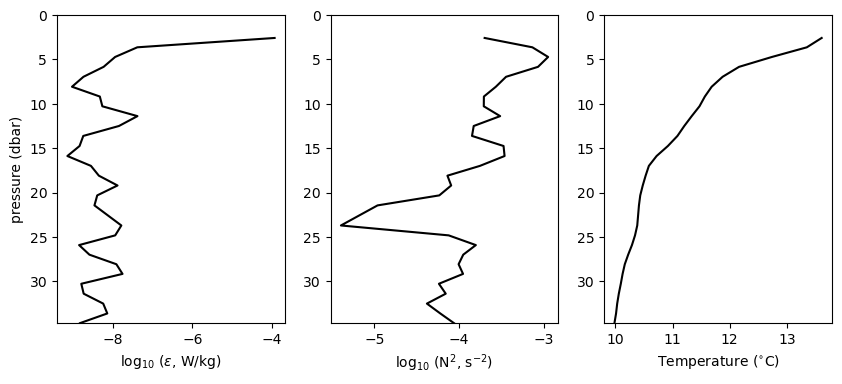

In [5]:
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.plot(np.log10(profile_5_2[:,1]), profile_5_2[:,0], 'k-')
plt.xlabel('log$_{10}$ ($\\varepsilon$, W/kg)')
plt.ylabel('pressure (dbar)')
plt.ylim([np.max(profile_5_2[:,0]), 0])

plt.subplot(1,3,2)
plt.plot(np.log10(profile_5_2[:,2]), profile_5_2[:,0], 'k-')
plt.xlabel('log$_{10}$ (N$^2$, s$^{-2}$)')
plt.ylim([np.max(profile_5_2[:,0]), 0])

plt.subplot(1,3,3)
plt.plot(profile_5_2[:,3], profile_5_2[:,0], 'k-')
plt.xlabel('Temperature ($^{\\circ}$C)')
plt.ylim([np.max(profile_5_2[:,0]), 0])

plt.show()

## Visualizing the transects
Since these profiles were collected along transect, it's helpful to visualize them in terms of the distance along the transect. The provided script provides a convenient function for this type of plot. Note that you can pass in the key words "epsilon", "N2", or "temperature" to generate the plot for that data:

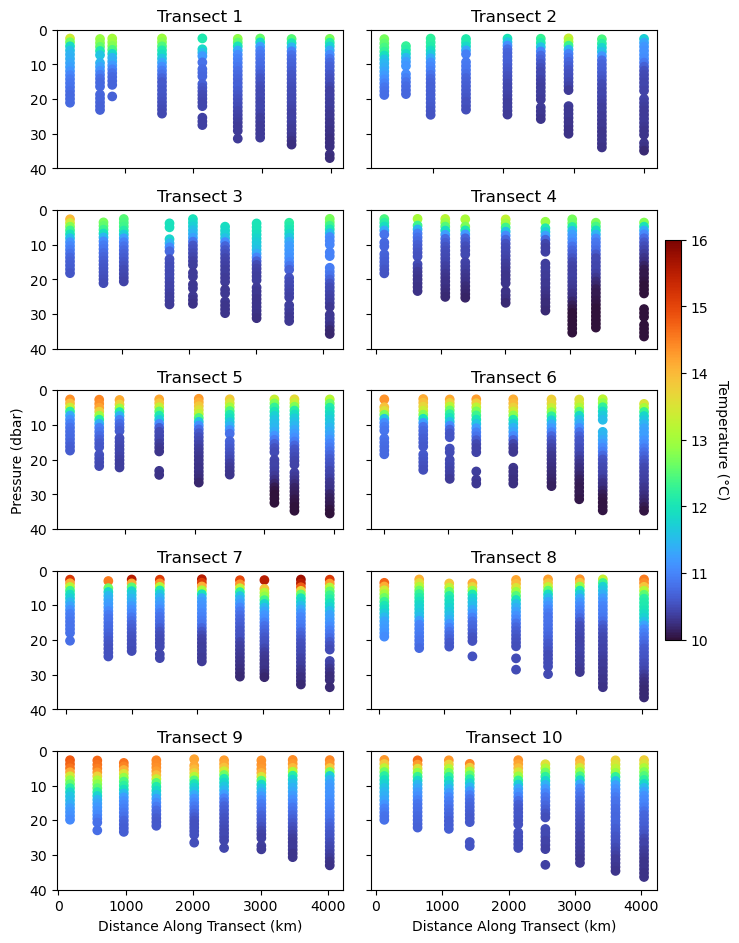

In [6]:
tehf.plot_transect_profiles(transect_sets, 'temperature')

By changing the variable plotted above, you likely noticed some differences between the variables. However, it's a little difficult to track these differences across the different variables and transect - this is where a clustering approach can help us out.

## Clustering 

In the steps below, we will assign unique values to groups of different data. For example, one prominent group might be warm, stable, near-surface waters. We will do this using the clustering algorithms introduced in the previous notebooks. As for any machine learning algorithm, first we will need our design matrix:

In [7]:
# make an empty list for the profile stack
profiles = []

# make an empty list for the transect and profile numbers
transect_profile_numbers = []

# loop through each profile and add it to the list
for transect_number in transect_sets.keys():
    for profile_number in transect_sets[transect_number].keys():
        profile = transect_sets[transect_number][profile_number].copy()
        profile = np.column_stack([profile[:,1], profile[:,2], profile[:,3]])

        # now, log transform epsilon and N2
        profile[:,0] = np.log10(profile[:,0])
        profile[:,1] = np.log10(profile[:,1])
        
        # non_nan_indices = np.logical_and(~np.isnan(profile[:,0]), ~np.isnan(profile[:,1]))
        # profile = profile[non_nan_indices, :]
        profiles.append(profile)
        transect_profile_number = np.ones_like(profile[:,:2])
        transect_profile_number[:,0] *= transect_number
        transect_profile_number[:,1] *= profile_number
        transect_profile_numbers.append(transect_profile_number)

# construct the design matrix
X = np.vstack(profiles)
TP = np.vstack(transect_profile_numbers)

Before applying our clustering algorithm we need to standardize the data as each variable is on a different scale:

In [8]:
X_std = (X - np.nanmean(X, axis=0)) / np.nanstd(X, axis=0)

With our data in hand, we're ready to test out our clustering algorithm. As a first guess, let's use the simple $k$-Means clustering:

In [9]:
n_clusters = 5
C = KMeans(n_clusters=n_clusters, random_state=0).fit_predict(X_std)

## Visualize the Clustering Results

Let's have a look at our clustering results. Since our data is three-dimensional ($\varepsilon$, N$^2$, and temperature), we can look at our clustering results along "orthogonal" axes between variables:

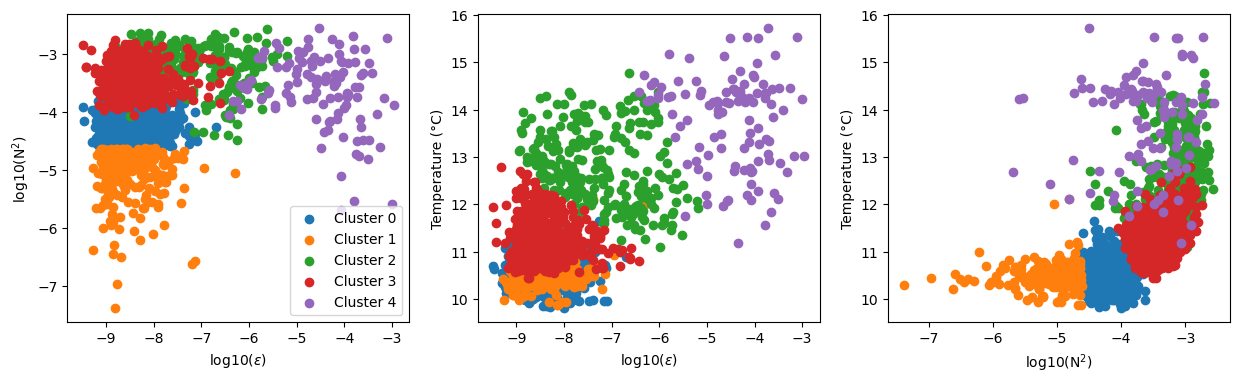

In [10]:
unique_clusters = np.unique(C)

fig = plt.figure(figsize=(15, 4))
plt.subplot(1,3,1)
for cluster in unique_clusters:
    cluster_points = X[C == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label='Cluster ' + str(cluster))
plt.xlabel('log10($\\varepsilon$)')
plt.ylabel('log10(N$^2$)')
plt.legend()

plt.subplot(1,3,2)
for cluster in unique_clusters:
    cluster_points = X[C == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 2], label='Cluster ' + str(cluster))
plt.xlabel('log10($\\varepsilon$)')
plt.ylabel('Temperature (°C)')

plt.subplot(1,3,3)
for cluster in unique_clusters:
    cluster_points = X[C == cluster]
    plt.scatter(cluster_points[:, 1], cluster_points[:, 2], label='Cluster ' + str(cluster))
plt.xlabel('log10(N$^2$)')
plt.ylabel('Temperature (°C)')

plt.show()

From these results, we can see that our clustering is picking out domains in each variable space corresponding to a given regime. For example, cluster 3 corresponds to highly stable, low mixing regime with moderate temperature. Let's see where that cluster sits in the water column. Again, a helper function is used for this plot:

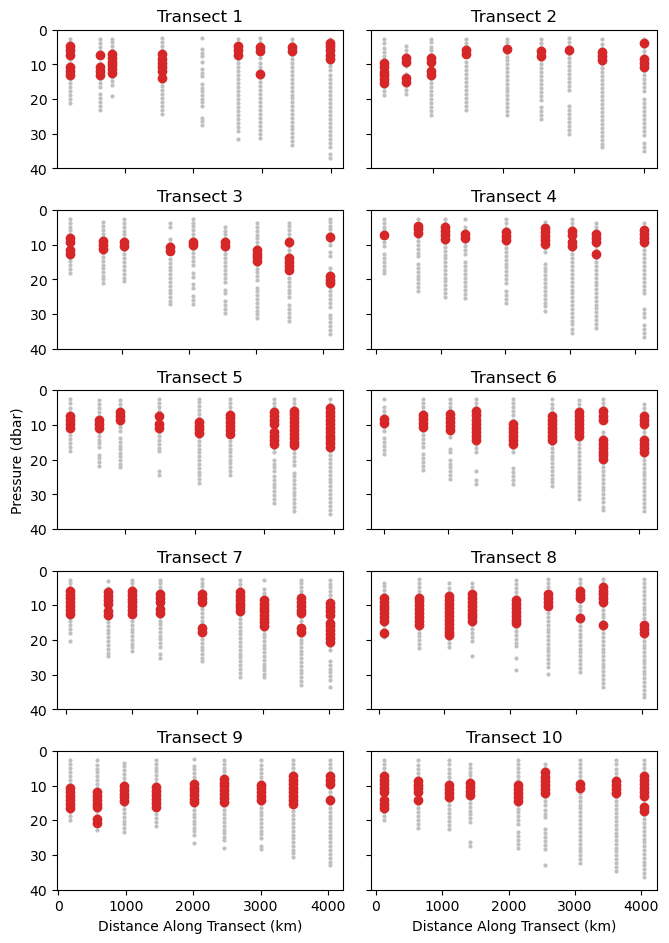

In [11]:
tehf.plot_clustering_results(transect_sets, C, TP, n_clusters, plot_cluster=3)

In the above example, we can see that the cluster 3 water is typically positioned at a depth of 5-20 m but there are significant variations between and across transects. This analysis could provide a valuable starting points for investigating different mixing regimes in this region of the ocean.

### &#x1F914; Try it yourself
There's a lot to explore in this data. Using the example above try out the following:
1. Examine the depths of other clustered points in the water column. Does this match with you intuition?
2. Try out different numbers of clusters in the $k$-Means algorithm. How do the number of clusters change the result?
3. Try our a different clustering algorithm. In the previous notebook, we saw two example of density-based clustering (DBSCAN and OPTICS). How do the results of these algorithms compare to that from $k$-means?